# НИРМ3 — неделя 4: метки, разбиение на выборки, протокол оценки и классический baseline

Продолжение `nirm3_week3_ptbxl.ipynb` (использует его кэш: `cache/X100_bp05-40_crop.npy`,
`cache/preprocessing.json`, `cache/quality_full.csv`).

Задачи недели 4:
1. Многометочная постановка: матрица меток 5 суперклассов, записи без диагноза, сочетания классов.
2. Разбиение по официальному `strat_fold`: 1–8 — обучение, 9 — валидация, 10 — тест; проверка баланса
   классов, пола, возраста и качества сигналов между выборками.
3. Протокол оценки, общий для всех моделей года 2: macro-AUC, AUC по классам, бутстреп-интервалы,
   оценка отдельно по полу, порог для скрининга по валидационному фолду.
4. Классический baseline: признаки сигнала + XGBoost (продолжение линии года 1) — нижняя планка
   для 1D-CNN недели 5.

Все выборки — `random_state=42`, датасет — PTB-XL v1.0.3, формат — `records100`.

In [1]:
%pip install wfdb xgboost --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import ast
import glob
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.signal import find_peaks, welch
from scipy.stats import kurtosis, skew, spearmanr
from sklearn.metrics import roc_auc_score

SEED = 42
DATA_PATH = os.path.dirname(glob.glob('**/ptbxl_database.csv', recursive=True)[0]) + os.sep
CACHE = 'cache' + os.sep
FIG_DIR = CACHE + 'fig' + os.sep
assert os.path.exists(CACHE + 'X100_bp05-40_crop.npy'), 'сначала выполните ноутбук недели 3 — он создаёт кэш'
plt.rcParams.update({'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3})

df = pd.read_csv(DATA_PATH + 'ptbxl_database.csv', index_col='ecg_id')
df['scp_codes'] = df.scp_codes.apply(ast.literal_eval)
scp = pd.read_csv(DATA_PATH + 'scp_statements.csv', index_col=0)
scp = scp[scp.diagnostic == 1]
SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
df['superclass'] = df.scp_codes.apply(lambda codes: sorted({scp.loc[c].diagnostic_class
                                                            for c in codes if c in scp.index}))
df['sex_label'] = df.sex.map({0: 'male', 1: 'female'})

X = np.load(CACHE + 'X100_bp05-40_crop.npy')
prep = json.load(open(CACHE + 'preprocessing.json'))
q = pd.read_csv(CACHE + 'quality_full.csv', index_col='ecg_id')
assert prep['ecg_ids'] == df.index.tolist()
LEADS, FS = prep['leads'], prep['fs']
print(f'X: {X.shape}, записей в метаданных: {len(df)}')

X: (21799, 900, 12), записей в метаданных: 21799


## Задача 1. Многометочная постановка задачи

Одна запись может иметь несколько суперклассов (например, MI и STTC одновременно), поэтому задача —
многометочная: 5 независимых бинарных выходов, а не один softmax.

In [3]:
Y = np.array([[c in v for c in SUPERCLASSES] for v in df.superclass], dtype=np.int8)
n_labels = Y.sum(axis=1)
has_label = n_labels > 0

print(f'записей без диагностического суперкласса: {(~has_label).sum()} ({(~has_label).mean()*100:.1f}%) '
      f'— исключаются из обучения и оценки')
print('число суперклассов на запись:',
      ', '.join(f'{k}: {v}' for k, v in pd.Series(n_labels[has_label]).value_counts().sort_index().items()))

combo = pd.Series(['+'.join(v) for v in df.superclass[has_label]]).value_counts()
print(f'\nуникальных сочетаний: {len(combo)}; самые частые:\n{combo.head(8).to_string()}')

Y_int = Y[has_label].astype(np.int64)
co = pd.DataFrame(Y_int.T @ Y_int, index=SUPERCLASSES, columns=SUPERCLASSES)
co_pct = (co / np.diag(co)[:, None] * 100).round(1)
print('\nдоля записей класса-строки, у которых есть и класс-столбец, %:')
print(co_pct)

записей без диагностического суперкласса: 411 (1.9%) — исключаются из обучения и оценки
число суперклассов на запись: 1: 16244, 2: 4068, 3: 919, 4: 157

уникальных сочетаний: 22; самые частые:
NORM        9069
MI          2532
STTC        2400
CD          1708
CD+MI       1297
HYP+STTC     781
MI+STTC      599
HYP          535

доля записей класса-строки, у которых есть и класс-столбец, %:
       NORM     MI   STTC     CD    HYP
NORM  100.0    0.0    0.3    4.4    0.1
MI      0.0  100.0   24.5   32.8   15.0
STTC    0.6   25.6  100.0   20.4   28.8
CD      8.5   36.6   21.8  100.0   16.1
HYP     0.2   30.9   57.0   29.7  100.0


## Задача 2. Разбиение на обучающую, валидационную и тестовую выборки

PTB-XL поставляется с разбиением `strat_fold` (1–10): фолды стратифицированы по диагнозам, пациент
целиком попадает в один фолд, а фолды 9 и 10 по замыслу авторов датасета содержат только записи,
проверенные кардиологом. Стандартный протокол (Strodthoff et al., 2021): 1–8 — обучение,
9 — валидация, 10 — тест. Проверяем, что разбиение действительно сбалансировано.

In [4]:
SPLITS = {'train': list(range(1, 9)), 'val': [9], 'test': [10]}
split = df.strat_fold.map({f: name for name, folds in SPLITS.items() for f in folds}).to_numpy()
age = df.age.where(df.age != 300, 90)

rows = []
for name in SPLITS:
    m = (split == name) & has_label
    row = {'split': name, 'records': int(m.sum()), 'patients': df.patient_id[m].nunique()}
    row.update({f'{c}_%': round(Y[m, k].mean() * 100, 1) for k, c in enumerate(SUPERCLASSES)})
    row.update({'female_%': round((df.sex_label[m] == 'female').mean() * 100, 1),
                'age_median': age[m].median(),
                'validated_%': round(df.validated_by_human[m].mean() * 100, 1),
                'qc_flag_%': round(q.flag_any[m].mean() * 100, 1)})
    rows.append(row)
split_table = pd.DataFrame(rows).set_index('split')
print(split_table.T.to_string())

leak = df.groupby('patient_id').strat_fold.nunique()
print(f'\nпациентов в нескольких фолдах: {(leak > 1).sum()}')
prev = split_table[[f'{c}_%' for c in SUPERCLASSES]]
print(f'максимальное расхождение доли класса между выборками: {(prev.max() - prev.min()).max():.1f} п.п.')

split          train     val    test
records      17084.0  2146.0  2158.0
patients     14823.0  1917.0  1877.0
NORM_%          44.5    44.5    44.6
MI_%            25.6    25.2    25.5
STTC_%          24.5    24.6    24.1
CD_%            22.9    23.1    23.0
HYP_%           12.4    12.5    12.1
female_%        48.0    48.1    48.6
age_median      61.0    62.0    63.0
validated_%     67.8   100.0   100.0
qc_flag_%       25.1    27.3    26.9

пациентов в нескольких фолдах: 0
максимальное расхождение доли класса между выборками: 0.5 п.п.


In [5]:
# Хватит ли теста для оценки отдельно по полу: число положительных примеров каждого класса в фолде 10
test = (split == 'test') & has_label
sex_counts = pd.DataFrame({s: Y[test & (df.sex_label == s).to_numpy()].sum(axis=0)
                           for s in ('male', 'female')}, index=SUPERCLASSES)
sex_counts['female_share_%'] = (sex_counts.female / sex_counts.sum(axis=1) * 100).round(1)
print('положительных примеров в тестовом фолде по полу:')
print(sex_counts)

train = (split == 'train') & has_label
pos = Y[train].sum(axis=0)
pos_weight = (train.sum() - pos) / pos
print('\nдисбаланс в обучающей выборке (negative/positive): '
      + ', '.join(f'{c} {w:.2f}' for c, w in zip(SUPERCLASSES, pos_weight)))

положительных примеров в тестовом фолде по полу:
      male  female  female_share_%
NORM   516     447            46.4
MI     297     253            46.0
STTC   229     292            56.0
CD     266     230            46.4
HYP    135     127            48.5

дисбаланс в обучающей выборке (negative/positive): NORM 1.25, MI 2.90, STTC 3.08, CD 3.37, HYP 7.06


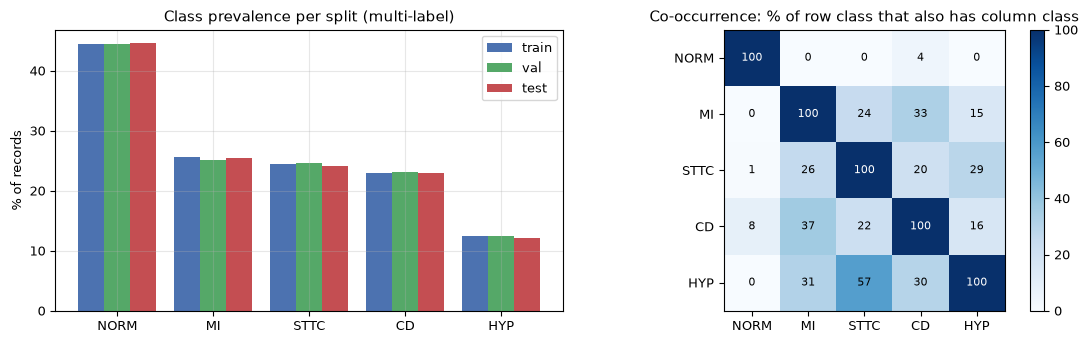

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
x = np.arange(len(SUPERCLASSES))
for k, (name, color) in enumerate((('train', '#4C72B0'), ('val', '#55A868'), ('test', '#C44E52'))):
    ax[0].bar(x + (k - 1) * 0.27, prev.loc[name], 0.27, label=name, color=color)
ax[0].set_xticks(x, SUPERCLASSES)
ax[0].set(ylabel='% of records', title='Class prevalence per split (multi-label)')
ax[0].legend()
im = ax[1].imshow(co_pct.values, cmap='Blues', vmin=0, vmax=100)
ax[1].set_xticks(x, SUPERCLASSES)
ax[1].set_yticks(x, SUPERCLASSES)
ax[1].grid(False)
for a in range(5):
    for b in range(5):
        ax[1].text(b, a, f'{co_pct.values[a, b]:.0f}', ha='center', va='center', fontsize=8,
                   color='white' if co_pct.values[a, b] > 60 else 'black')
ax[1].set_title('Co-occurrence: % of row class that also has column class')
plt.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout()
plt.savefig(FIG_DIR + 'w4_splits_cooccurrence.png', dpi=150)
plt.show()

## Задача 3. Протокол оценки

Один и тот же для всех моделей года 2, чтобы результаты были сравнимы между неделями:

- **macro-AUC** по 5 суперклассам на тестовом фолде 10 — основная метрика (как в бенчмарке
  Strodthoff et al., 2021), плюс AUC каждого класса;
- **95 % бутстреп-интервал** (1000 повторов по записям, `seed=42`);
- **оценка отдельно для мужчин и женщин** — продолжение результата года 1;
- **порог скрининга** подбирается на валидационном фолде 9: максимальный порог, при котором
  чувствительность класса ≥ 0.90; на тесте сообщаются чувствительность и специфичность при этом пороге.
  Тестовый фолд в подборе порогов не участвует.

In [7]:
N_BOOT = 1000
TARGET_SENS = 0.90


def macro_auc(y, s):
    return np.mean([roc_auc_score(y[:, k], s[:, k]) for k in range(y.shape[1])])


def bootstrap_ci(y, s, metric=macro_auc, n=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if (y[idx].sum(axis=0) > 0).all() and (y[idx].sum(axis=0) < len(idx)).all():
            vals.append(metric(y[idx], s[idx]))
    return np.percentile(vals, [2.5, 97.5])


def screening_thresholds(y_val, s_val, target=TARGET_SENS):
    th = []
    for k in range(y_val.shape[1]):
        pos_scores = np.sort(s_val[y_val[:, k] == 1, k])
        th.append(pos_scores[int(np.floor((1 - target) * len(pos_scores)))])
    return np.array(th)


def evaluate(y, s, sex, th):
    """Сводка по тесту: AUC и чувствительность/специфичность при пороге скрининга, всего и по полу."""
    rows = []
    for group, m in (('all', np.ones(len(y), bool)), ('male', sex == 'male'), ('female', sex == 'female')):
        for k, c in enumerate(SUPERCLASSES):
            yk, pred = y[m, k], s[m, k] >= th[k]
            rows.append({'group': group, 'class': c, 'n_pos': int(yk.sum()),
                         'AUC': roc_auc_score(yk, s[m, k]),
                         'sens': pred[yk == 1].mean(), 'spec': 1 - pred[yk == 0].mean()})
    res = pd.DataFrame(rows)
    macro = res.groupby('group', sort=False).AUC.mean()
    return res, macro

## Задача 4. Классический baseline: признаки сигнала + XGBoost

Признаки считаются по предобработанному сигналу (0.5–40 Гц, 9 с, мВ) — для каждого из 12 отведений:
СКО, размах, 5-й и 95-й перцентили, асимметрия, эксцесс, доли мощности в полосах 0.5–5, 5–15 и
15–40 Гц (9 × 12 = 108 признаков), плюс ритм по отведению II: ЧСС, СКО RR-интервалов, число
комплексов. Два варианта: только сигнал (сравнимо с 1D-CNN) и сигнал + возраст и пол
(заготовка гибридной модели). Для каждого суперкласса — отдельный бинарный XGBoost с ранней
остановкой по валидационному фолду.

In [8]:
BANDS = {'p_0.5-5': (0.5, 5), 'p_5-15': (5, 15), 'p_15-40': (15, 40)}


def signal_features(x):
    feats = {'std': x.std(axis=1), 'p2p': x.max(axis=1) - x.min(axis=1),
             'p5': np.percentile(x, 5, axis=1), 'p95': np.percentile(x, 95, axis=1),
             'skew': skew(x, axis=1), 'kurt': kurtosis(x, axis=1)}
    freqs, psd = welch(x, fs=FS, nperseg=256, axis=1)
    total = np.trapezoid(psd, freqs, axis=1) + 1e-12
    for name, (lo, hi) in BANDS.items():
        m = (freqs >= lo) & (freqs < hi)
        feats[name] = np.trapezoid(psd[:, m], freqs[m], axis=1) / total
    cols = {f'{lead}_{name}': v[:, j] for name, v in feats.items() for j, lead in enumerate(LEADS)}
    return pd.DataFrame(cols)


def rhythm_features(x, lead='II'):
    j = LEADS.index(lead)
    rows = []
    for sig in x[:, :, j]:
        sig = sig if np.abs(sig.max()) >= np.abs(sig.min()) else -sig
        peaks, _ = find_peaks(sig, distance=int(0.3 * FS), height=0.5 * sig.max())
        rr = np.diff(peaks) / FS
        rows.append({'hr': 60 / rr.mean() if len(rr) else np.nan,
                     'rr_std': rr.std() if len(rr) > 1 else np.nan, 'n_beats': len(peaks)})
    return pd.DataFrame(rows)


t0 = time.perf_counter()
F = pd.concat([signal_features(X[s:s + 4000]) for s in range(0, len(X), 4000)], ignore_index=True)
F = pd.concat([F, rhythm_features(X)], axis=1)
F.index = df.index
F_demo = F.assign(age=age.to_numpy(), sex=df.sex.to_numpy())
print(f'признаков: {F.shape[1]} (+2 демографических), посчитано за {time.perf_counter() - t0:.0f} с')
print(F[['hr', 'rr_std', 'n_beats']].describe().round(2).T)

признаков: 111 (+2 демографических), посчитано за 26 с
           count   mean    std   min    25%    50%    75%     max
hr       21395.0  73.10  18.11  7.07  62.18  70.77  81.78  200.00
rr_std   21200.0   0.06   0.13  0.00   0.01   0.02   0.05    2.82
n_beats  21799.0  10.72   3.05  0.00   9.00  11.00  12.00   30.00


In [9]:
XGB_PARAMS = dict(n_estimators=3000, learning_rate=0.03, max_depth=5, subsample=0.8, colsample_bytree=0.6,
                  min_child_weight=3, tree_method='hist', eval_metric='auc', early_stopping_rounds=100,
                  random_state=SEED, n_jobs=-1)
tr, va, te = [(split == s) & has_label for s in ('train', 'val', 'test')]
sex_te = df.sex_label.to_numpy()[te]


def fit_xgb(features):
    models, s_val, s_test = [], [], []
    for k in range(len(SUPERCLASSES)):
        m = xgb.XGBClassifier(**XGB_PARAMS)
        m.fit(features[tr], Y[tr, k], eval_set=[(features[va], Y[va, k])], verbose=False)
        models.append(m)
        s_val.append(m.predict_proba(features[va])[:, 1])
        s_test.append(m.predict_proba(features[te])[:, 1])
    return models, np.column_stack(s_val), np.column_stack(s_test)


results = {}
for name, feats in (('XGB: signal', F), ('XGB: signal + age, sex', F_demo)):
    t0 = time.perf_counter()
    models, s_val, s_test = fit_xgb(feats)
    th = screening_thresholds(Y[va], s_val)
    res, macro = evaluate(Y[te], s_test, sex_te, th)
    ci = bootstrap_ci(Y[te], s_test)
    results[name] = dict(models=models, s_val=s_val, s_test=s_test, res=res, macro=macro, ci=ci, th=th)
    print(f'{name}: test macro-AUC {macro["all"]:.3f} [95% CI {ci[0]:.3f}-{ci[1]:.3f}], '
          f'male {macro["male"]:.3f}, female {macro["female"]:.3f}; '
          f'деревьев {[m.best_iteration + 1 for m in models]}; {time.perf_counter() - t0:.0f} с')

XGB: signal: test macro-AUC 0.894 [95% CI 0.886-0.902], male 0.900, female 0.888; деревьев [611, 642, 320, 298, 260]; 47 с


XGB: signal + age, sex: test macro-AUC 0.897 [95% CI 0.889-0.905], male 0.904, female 0.891; деревьев [619, 388, 267, 292, 296]; 41 с


In [10]:
for name, r in results.items():
    print(f'\n{name}')
    print(r['res'].pivot(index='class', columns='group', values='AUC')[['all', 'male', 'female']]
          .loc[SUPERCLASSES].round(3).to_string())

base = results['XGB: signal + age, sex']
print('\nпорог скрининга (чувствительность ≥ 0.90 на валидации), тест, модель signal + age, sex:')
print(base['res'].pivot(index='class', columns='group', values=['sens', 'spec'])
      .loc[SUPERCLASSES].round(3).to_string())


XGB: signal
group    all   male  female
class                      
NORM   0.918  0.918   0.918
MI     0.861  0.868   0.852
STTC   0.912  0.927   0.896
CD     0.884  0.891   0.878
HYP    0.894  0.897   0.893

XGB: signal + age, sex
group    all   male  female
class                      
NORM   0.923  0.923   0.923
MI     0.867  0.876   0.857
STTC   0.914  0.927   0.900
CD     0.885  0.895   0.877
HYP    0.897  0.897   0.897

порог скрининга (чувствительность ≥ 0.90 на валидации), тест, модель signal + age, sex:
        sens                 spec              
group    all female   male    all female   male
class                                          
NORM   0.906  0.895  0.915  0.784  0.774  0.795
MI     0.871  0.846  0.892  0.666  0.691  0.642
STTC   0.883  0.880  0.886  0.783  0.754  0.808
CD     0.881  0.852  0.906  0.640  0.694  0.586
HYP    0.878  0.874  0.881  0.707  0.714  0.701


In [11]:
# Разница между мужчинами и женщинами по классам: бутстреп-интервал разности AUC (female - male)
s_test = base['s_test']
y_te = Y[te]
rng = np.random.default_rng(SEED)
male_idx, female_idx = np.where(sex_te == 'male')[0], np.where(sex_te == 'female')[0]
gap_rows = []
for k, c in enumerate(SUPERCLASSES):
    diffs = []
    for _ in range(N_BOOT):
        mi, fi = rng.choice(male_idx, len(male_idx)), rng.choice(female_idx, len(female_idx))
        diffs.append(roc_auc_score(y_te[fi, k], s_test[fi, k]) - roc_auc_score(y_te[mi, k], s_test[mi, k]))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    point = (roc_auc_score(y_te[female_idx, k], s_test[female_idx, k])
             - roc_auc_score(y_te[male_idx, k], s_test[male_idx, k]))
    gap_rows.append({'class': c, 'AUC female - male': round(point, 3), 'CI low': round(lo, 3),
                     'CI high': round(hi, 3), 'significant': not (lo <= 0 <= hi)})
sex_gap = pd.DataFrame(gap_rows).set_index('class')
print(sex_gap)

       AUC female - male  CI low  CI high  significant
class                                                 
NORM               0.000  -0.021    0.022        False
MI                -0.019  -0.052    0.014        False
STTC              -0.027  -0.054   -0.003         True
CD                -0.018  -0.055    0.017        False
HYP               -0.000  -0.041    0.041        False


### Какие признаки модель использует у мужчин и у женщин

Продолжение анализа года 1 (асимметрия признаков по полу на Cleveland). Для модели MI считаем
вклад признаков TreeSHAP (встроен в XGBoost, `pred_contribs=True`) отдельно на тестовых записях
мужчин и женщин и сравниваем ранжирование.

In [12]:
k_mi = SUPERCLASSES.index('MI')
mi_model = results['XGB: signal']['models'][k_mi]
contrib = mi_model.get_booster().predict(xgb.DMatrix(F[te]), pred_contribs=True)[:, :-1]
imp = pd.DataFrame({s: np.abs(contrib[sex_te == s]).mean(axis=0) for s in ('male', 'female')}, index=F.columns)
imp['rank_male'] = imp.male.rank(ascending=False).astype(int)
imp['rank_female'] = imp.female.rank(ascending=False).astype(int)
rho = spearmanr(imp.male, imp.female).statistic
top = imp.sort_values('male', ascending=False).head(10)
print(f'MI, mean |SHAP| на тесте; корреляция Спирмена важностей male vs female: {rho:.3f}')
print(top.round(4).to_string())
only_top = set(imp.nsmallest(10, 'rank_male').index) ^ set(imp.nsmallest(10, 'rank_female').index)
print(f'\nпризнаки, входящие в топ-10 только у одного пола: {sorted(only_top)}')

MI, mean |SHAP| на тесте; корреляция Спирмена важностей male vs female: 0.991
              male  female  rank_male  rank_female
AVR_p5      0.2300  0.2133          1            2
V3_p5       0.1986  0.2299          2            1
V2_p_15-40  0.1860  0.1888          3            3
V6_p_15-40  0.1718  0.1713          4            5
III_p5      0.1661  0.1660          5            6
III_skew    0.1635  0.1750          6            4
III_std     0.1514  0.1606          7            7
AVL_p5      0.1310  0.1365          8            8
AVF_skew    0.1233  0.1216          9           11
V1_p_0.5-5  0.1188  0.1322         10            9

признаки, входящие в топ-10 только у одного пола: ['AVF_skew', 'V3_p_0.5-5']


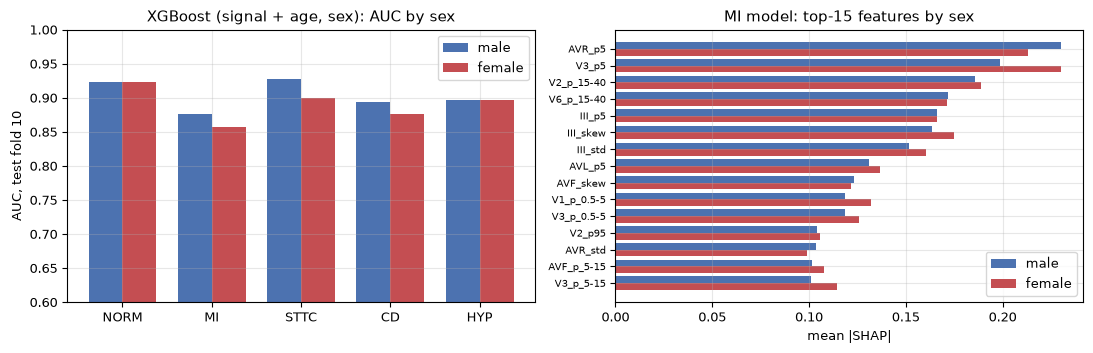

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
auc_tab = base['res'].pivot(index='class', columns='group', values='AUC').loc[SUPERCLASSES]
for k, (g, color) in enumerate((('male', '#4C72B0'), ('female', '#C44E52'))):
    ax[0].bar(x + (k - 0.5) * 0.38, auc_tab[g], 0.38, label=g, color=color)
ax[0].set_xticks(x, SUPERCLASSES)
ax[0].set(ylim=(0.6, 1.0), ylabel='AUC, test fold 10', title='XGBoost (signal + age, sex): AUC by sex')
ax[0].legend()
top15 = imp.sort_values('male', ascending=False).head(15).iloc[::-1]
yy = np.arange(len(top15))
ax[1].barh(yy + 0.2, top15.male, 0.4, color='#4C72B0', label='male')
ax[1].barh(yy - 0.2, top15.female, 0.4, color='#C44E52', label='female')
ax[1].set_yticks(yy, top15.index, fontsize=7)
ax[1].set(xlabel='mean |SHAP|', title='MI model: top-15 features by sex')
ax[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR + 'w4_xgb_sex.png', dpi=150)
plt.show()

In [14]:
np.savez(CACHE + 'labels_splits.npz', Y=Y, split=split, has_label=has_label, ecg_ids=df.index.to_numpy())
np.savez(CACHE + 'xgb_scores.npz', **{f'{key}_{i}': r[key] for i, r in enumerate(results.values())
                                      for key in ('s_val', 's_test')})
print('сохранено:', 'labels_splits.npz, xgb_scores.npz')

сохранено: labels_splits.npz, xgb_scores.npz


## Выводы недели 4

**Метки.** 411 записей (1.9 %) без диагностического суперкласса исключены. Многометочность существенна:
у 5 144 записей два и более суперкласса, всего 22 уникальных сочетания. Сильнее всего связаны HYP и STTC
(57 % записей с гипертрофией имеют и STTC), CD и MI (36.6 %). NORM почти не сочетается с патологиями
(не более 4.4 %), поэтому выход NORM и выходы патологий модель учит фактически как противоположные.

**Разбиение.** Официальный `strat_fold` пригоден как есть: обучение 17 084 / валидация 2 146 / тест 2 158
записей, доли классов расходятся не более чем на 0.5 п.п., доля женщин 48.0–48.6 %, пациенты между фолдами
не пересекаются. Фолды 9 и 10 полностью проверены кардиологом, в обучении таких 67.8 % — метки в тесте
чище, чем в обучении. В тесте достаточно примеров обоих полов для раздельной оценки (от 127 женщин с HYP
до 516 мужчин с NORM).

**Классический baseline.** 113 признаков сигнала и ритма + XGBoost: macro-AUC 0.894 [0.886–0.902], с
возрастом и полом — 0.897 [0.889–0.905]. Это выше опубликованного признакового baseline Wavelet+NN (0.874) и
ниже лучших CNN (≈0.93): планка, которую 1D-CNN недели 5 должна заметно превзойти. Демография добавляет
лишь +0.003 — почти вся информация уже содержится в сигнале.

**Различия по полу.** macro-AUC у мужчин 0.904, у женщин 0.891. По отдельным классам значима только разница
для STTC (−0.027 [−0.054; −0.003] у женщин; без поправки на множественные сравнения). Важнее другое: при
одном пороге скрининга, подобранном на валидации для всех, чувствительность у женщин ниже — MI 0.846 против
0.892, CD 0.852 против 0.906. Это повторяет мотив года 1: порог нужно подбирать с учётом пола.

**Признаки по полу.** Для модели MI ранжирование TreeSHAP у мужчин и женщин почти одинаково (Спирмен 0.991,
топ-10 совпадает на 9 из 10). В отличие от табличных данных Cleveland, на признаках сигнала асимметрия
проявляется не в том, *какие* признаки использует модель, а в том, *насколько хорошо* она распознаёт.
Проверить это на картах значимости CNN — задача недель 9–10.

## План на неделю 5

1. Baseline 1D-CNN (`ResNet1d`, вариант `resnet1d_wang`) на `records100`.
2. Оценка по протоколу этой недели, отдельно по полу, с порогом скрининга.
3. Парное сравнение с XGBoost на одних и тех же тестовых записях.
4. Абляция нормировки: статистика фолдов 1–8 против z-score каждой записи.